# 05 — forebrain / midbrain subclustering

**Feeds:** ED Fig 7b

**Position in the chain:** run the numbered stages in order

Ported from the original analysis. Saved cell outputs are from the original run, and paths in them appear as `<analysis-root>/...`.

**Changes from the original notebook**, so that it runs from this repository:
1. Paths. The first code cell finds the repository from any working directory inside it; the original looked for `src/` at most two levels up. `PROJECT_ROOT`, which was the analysis directory, is now `scrnaseq/chain_inputs/`, the shipped files that no notebook writes, in the same layout. `DEV_ROOT`, under which the notebook writes, is `$SCRNASEQ_RESULTS_ROOT/trunk_main_dev/` (default `scrnaseq/output/trunk_main_dev/`) instead of the analysis directory's `trunk_main_dev/`.
2. The SMD z-score files are read from `scrnaseq/chain_inputs/trunk_main_dev/results/smd_runs/` (`PROJECT_ROOT / "trunk_main_dev" / "results"`) instead of `RESULTS_DIR`, where they sat in the original analysis directory.
3. Removed the `.to_clipboard()` call, which copied a table to the system clipboard for pasting into the Supplementary Data spreadsheet and fail on a machine without a clipboard. The expression before each call is unchanged.
4. The forebrain / midbrain subcluster labels come from one `sc.tl.leiden` call on the selected-gene graph (resolution 1.15, seed 2, `flavor="igraph"`, `n_iterations=-1`, as `03` calls it), with the cluster-id to name map written into the cell. The original read the same run's labels and names from files saved by a separate clustering-stability analysis that is not part of this repository. `sc.tl.leiden` writes the raw cluster ids to `obs["leiden_morph_fbmb_raw"]`. The cell then overwrites that column with the suffixed cluster names, as before. In the saved `meta.json`, `ensemble_default_label_source` holds that analysis's relative directory instead of an absolute path; the other strings naming the label source are unchanged.

No other line of code was changed.


# 05 - Forebrain/Midbrain Subclustering

Depends on: 01_preprocessing, 02_trunk_main artifacts.

In [ ]:
from pathlib import Path
import sys

for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "src" / "trunk_morph_ref").exists():
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate the repository root containing src/trunk_morph_ref/")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.trunk_morph_ref.paths import chain_inputs_root

# Inputs that no notebook writes: scrnaseq/chain_inputs/, laid out as the original analysis directory.
PROJECT_ROOT = chain_inputs_root(REPO_ROOT)

import os
os.chdir(REPO_ROOT)


## Setup and Imports


In [ ]:
import matplotlib

matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

In [ ]:
import pickle
import random

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy
import seaborn as sns
from cmcrameri.cm import batlow
from scipy.sparse import coo_matrix, csr_matrix, load_npz, save_npz

/opt/anaconda3/lib/python3.12/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version


/opt/anaconda3/lib/python3.12/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/opt/anaconda3/lib/python3.12/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/opt/anaconda3/lib/python3.12/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/opt/anaconda3/lib/python3.12/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/opt/anaconda3

In [ ]:
plt.rcParams["svg.fonttype"] = "none"  # Keep fonts editable in Illustrator

In [ ]:
from src.trunk_morph_ref.cell_ordering import ordered_cells_by_cluster_clustermap
from src.trunk_morph_ref.paths import init_output_paths, scrnaseq_results_root

# Outputs: $SCRNASEQ_RESULTS_ROOT (default scrnaseq/output/), under trunk_main_dev/ as in the original.
DEV_ROOT = scrnaseq_results_root(REPO_ROOT) / "trunk_main_dev"
RESULTS_DIR, MANUSCRIPT_FIG_DIR, EXTENDED_FIG_DIR = init_output_paths(DEV_ROOT)
from src.trunk_morph_ref.aggregation import (
    cluster_averages_sparse_safe,
)
from src.trunk_morph_ref.correlation import (
    gene_corrcoef_sparse_safe,
)
from src.trunk_morph_ref.plotting import (
    bold_selected_heatmap_yticklabels,
    hide_heatmap_axes_and_colorbar,
    keep_only_selected_heatmap_yticklabels,
    plot_empty_heatmap_axes,
)
from src.trunk_morph_ref.preprocessing import (
    assert_gene_id_index,
    build_legacy_smd_score_table,
    contains_symbol,
    ensure_gene_id_index,
    filter_genes_sparse_safe as filter_genes,
    install_scanpy_symbol_defaults,
    map_legacy_smd_scores_to_adata,
    normalize_unit_variance_sparse_safe as normalize_unit_variance,
    resolve_symbol_dict,
    resolve_symbols,
    symbols_missing,
    symbols_present,
    var_names_to_symbols,
)

# Use gene symbols for plot labels while keeping `var_names` as stable gene IDs.
install_scanpy_symbol_defaults(sc)

In [ ]:
from src.trunk_morph_ref.pipeline_io import (
    load_h5ad,
    load_npy,
    load_pickle,
    save_h5ad,
    save_json,
    save_npy,
    save_pickle,
    stage_dir,
)

In [ ]:
pre_path = stage_dir(RESULTS_DIR, "01_preprocessing")
trunk_path = stage_dir(RESULTS_DIR, "02_trunk_main")
adata_morph_raw = load_h5ad(pre_path / "adata_morph_raw.h5ad")
adata_morph_with_clusters = load_h5ad(trunk_path / "adata_morph_with_clusters.h5ad")
for _adata in [
    adata_morph_raw,
    adata_morph_with_clusters,
]:
    ensure_gene_id_index(_adata)
    assert_gene_id_index(_adata)

print("Loaded 01_preprocessing and 02_trunk_main intermediates")

Loaded 01_preprocessing and 02_trunk_main intermediates


## Forebrain/Midbrain Subclustering Analysis
Pre-processing for the forebrain/midbrain subset.


### FB/MB Provenance Note

This notebook loads the following staged inputs from inside `trunk_main_dev`:

- `<analysis-root>/trunk_main_dev/results/intermediates/01_preprocessing/adata_morph_raw.h5ad`
- `<analysis-root>/trunk_main_dev/results/intermediates/02_trunk_main/adata_morph_with_clusters.h5ad`
- `<analysis-root>/trunk_main_dev/results/smd_runs/trunk_morph_fbmb__run001/z_trunk_morph_fbmb__smd_input_001.npy`

Notebook `05` now uses the local modern FB/MB SMD run, applies the simplified `02`-style gene-selection rule (`z > cutoff`, then remove cell-cycle genes), and exports the resulting precluster substrates for downstream `leiden_ensemble` analysis.


In [ ]:
genes_cellcycle = [
    "MKI67",
    "CENPE",
    "SGO2",
    "KIF14",
    "PIF1",
    "NDC80",
    "CDCA8",
    "PLK1",
    "AURKA",
    "UBE2C",
    "ASPM",
    "TOP2A",
    "TPX2",
    "NUSAP1",
    "CDC20",
    "CKS2",
    "KPNA2",
    "TUBB4B",
    "DLGAP5",
    "BIRC5",
    "HMMR",
    "CCNB1",
    "ARL6IP1",
    "PTTG1",
    "UBE2S",
    "DUT",
    "HELLS",
    "CLSPN",
    "RRM2",
    "PCLAF",
    "TYMS",
    "KIF18B",
    "SMC4",
    "HIST1H4C",
    "DIAPH3",
    "RFC3",
    "MIR924HG",
    "MIS18BP1",
    "TUBA1C",
    "CDK1",
    "CENPA",
    # extra genes added after mesoderm subclustering, were not already in SMD gene list
    "KIF11",
    "ECT2",
    "KNL1",
    "NEK2",
    "CEP55",
    "PSRC1",
    "CDCA3",
    "CCNA2",
    "GTSE1",
    "CENPF",
    "CKS1B",
    "MELK",
    "CDCA5",
    # Added 4/8 during LPM sub-subclustering
    "MCM4",
    "HIST1H1E",
    "BRCA2",
    "TRIM66",
    "C1orf112",
    "POLD3",
    "KIF23",
    # Added 4/8 part 2
    "CDKAL1",
    "RAD51AP1",
    "RANBP1",
    "CDCA2",
    "CAND2",
    "PCLAF",
    "EIF5A",
    "SRSF2",
    "GINS1",
    "GINS2",
    # Added 4/9 Neuron subclustering
    "ncAPG2",
    "CCND1",
    "ATAD2",
    "UBE2T",
    "CENPK",
    "LAPTM4B",
    "CCND2",
    "MED13",
    "ZNF37A",
    "PTPN14",
    # 4/10 Neural Crest
    "ncAPG",
    "TTK",
    "KIF4A",
    "KIF18A",
    "CDKN3",
    "CEP70",
    "BRIP1",
    "SPC25",
    "KIFC1",
    "NSD2",
    "BUB1",
    "BUB1B",
    "ANP32E",
    "HMGB3",
    "PCNA",
    "CENPP",
    # 4/10 Roof plate
    "CCT5",
    "KIF15",
    "CSRP2",
    "ORC6",
    "HMGB2",
]

NOTEBOOK_DPI = 110


In [ ]:
# Repeat preprocessing / gene filtering for forebrain/midbrain cells alone
adata_morph_fbmb = adata_morph_raw.copy()

# Filter for cells more than 5k reads
fbmb_minimum_reads = 5000
sc.pp.filter_cells(adata_morph_fbmb, min_counts=fbmb_minimum_reads)

# Downsample such that each cell has 10k reads
sc.pp.downsample_counts(
    adata_morph_fbmb, counts_per_cell=fbmb_minimum_reads, replace=True, random_state=0
)


adata_morph_fbmb.obs["leiden_morph"] = adata_morph_with_clusters.obs[
    "leiden_morph"
].reindex(adata_morph_fbmb.obs_names)
missing_cluster_labels = int(adata_morph_fbmb.obs["leiden_morph"].isna().sum())
if missing_cluster_labels:
    print(
        f"Dropping {missing_cluster_labels} cells not present in adata_morph_with_clusters "
        "before coarse-cluster subsetting."
    )
    adata_morph_fbmb = adata_morph_fbmb[
        adata_morph_fbmb.obs["leiden_morph"].notna()
    ].copy()
assert adata_morph_fbmb.obs["leiden_morph"].notna().all()

Dropping 44 cells not present in adata_morph_with_clusters before coarse-cluster subsetting.


In [ ]:
fbmb_clusters = ["Forebrain / Midbrain"]

# Select cells that are in fbmb clusters
adata_morph_fbmb = adata_morph_fbmb[
    (adata_morph_fbmb.obs.leiden_morph.isin(fbmb_clusters).values)
]

# Log-transform read counts
sc.pp.log1p(adata_morph_fbmb)

# For SMD analysis:
# Filter for log-transformed genes with mean value greater than 0.05 and standard deviation greater than 0.05
adata_morph_fbmb_filtered = filter_genes(
    adata_morph_fbmb, mean_cutoff=0.05, std_cutoff=0.05
)
# Normalize each gene to have unit variance in expression
adata_morph_fbmb_filtered = normalize_unit_variance(adata_morph_fbmb_filtered)

8693 genes after filtering


/opt/anaconda3/lib/python3.12/site-packages/scanpy/preprocessing/_simple.py:406: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [ ]:
# Filter for coefficient of variation (std deviation / mean) > 1
# Since we have normalized to unit variance this is just a mean cutoff < 1
counts = adata_morph_fbmb_filtered.X
cv_mask = np.mean(counts, axis=0).transpose() < 1
adata_morph_fbmb_filtered = adata_morph_fbmb_filtered[:, cv_mask]

In [ ]:
# Save pre-processed expression data to .npz file, for input to SMD on cluster
fbmb_stage_path = RESULTS_DIR / "intermediates" / "05_fbmb_subclustering"
fbmb_stage_path.mkdir(parents=True, exist_ok=True)
legacy_fbmb_input_path = fbmb_stage_path / "morph_fbmb4.03.npz"
canonical_fbmb_input_path = fbmb_stage_path / "trunk_morph_fbmb__smd_input.npz"
for _path in [legacy_fbmb_input_path, canonical_fbmb_input_path]:
    scipy.sparse.save_npz(_path, adata_morph_fbmb_filtered.X)
recommended_n_sub = int(round(0.8 * len(adata_morph_fbmb_filtered)))
save_json(
    {
        "stage": "05_fbmb_subclustering",
        "subset_name": "fbmb",
        "subset_clusters": fbmb_clusters,
        "minimum_reads": fbmb_minimum_reads,
        "legacy_smd_input_file": legacy_fbmb_input_path.name,
        "canonical_smd_input_file": canonical_fbmb_input_path.name,
        "n_cells_after_preprocessing": int(adata_morph_fbmb_filtered.n_obs),
        "n_genes_after_preprocessing": int(adata_morph_fbmb_filtered.n_vars),
        "recommended_n_sub": recommended_n_sub,
        "status": "ready_for_smd",
    },
    fbmb_stage_path / "pre_smd_input_meta.json",
)
print(
    f"{len(adata_morph_fbmb_filtered)} cells after pre-processing\n"
    f"{adata_morph_fbmb_filtered.shape[1]} genes after preprocessing\n"
    f"Recommended n_sub ~= {recommended_n_sub}"
)


487 cells after pre-processing
7943 genes after preprocessing
Recommended n_sub ~= 390


In [ ]:
# For downstream analysis after SMD:
# Only filter genes for non-zero mean and standard deviation:
adata_morph_fbmb_nofilter = adata_morph_fbmb.copy()
adata_morph_fbmb = filter_genes(adata_morph_fbmb, mean_cutoff=0, std_cutoff=0)
adata_morph_fbmb = normalize_unit_variance(adata_morph_fbmb)

20334 genes after filtering


### Post-SMD processing

/var/folders/l_/r6wv9rf56fb1h8jjvhh7rl440000gp/T/ipykernel_21831/545201343.py:23: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata_morph_fbmb_filtered.var["z_score_morph_fbmb"] = z_scores_morph_fbmb


  run_id n_sub trials kmax k_prior_min  n_genes_z_gt_2        max_z
0    001   390  15000   30           4             276  1160.833544


276 morph_fbmb genes with z_score >= cutoff


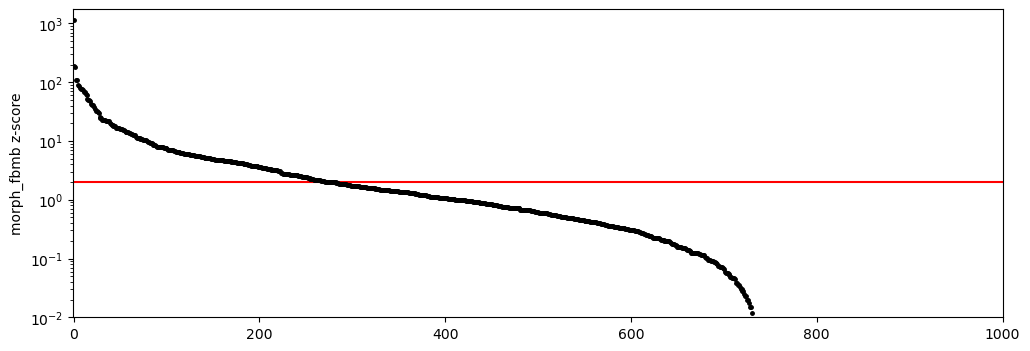

In [ ]:
# Load modern FB/MB SMD runs from local trunk_main_dev results
fbmb_smd_run_order = ["001"]
fbmb_smd_run_dirs = {
    "001": PROJECT_ROOT / "trunk_main_dev" / "results" / "smd_runs" / "trunk_morph_fbmb__run001",
}
fbmb_smd_runs = {
    run_id: load_npy(
        fbmb_smd_run_dirs[run_id] / f"z_trunk_morph_fbmb__smd_input_{run_id}.npy"
    )
    for run_id in fbmb_smd_run_order
}
selected_fbmb_smd_run = "001"
fbmb_smd_run_name = f"trunk_morph_fbmb__run{selected_fbmb_smd_run}"
fbmb_smd_zscore_name = f"z_trunk_morph_fbmb__smd_input_{selected_fbmb_smd_run}.npy"
z_scores_morph_fbmb = fbmb_smd_runs[selected_fbmb_smd_run]

if len(z_scores_morph_fbmb) != adata_morph_fbmb_filtered.n_vars:
    raise ValueError(
        "FB/MB SMD z-score length does not match filtered gene space: "
        f"{len(z_scores_morph_fbmb)} vs {adata_morph_fbmb_filtered.n_vars}"
    )

adata_morph_fbmb_filtered.var["z_score_morph_fbmb"] = z_scores_morph_fbmb
adata_morph_fbmb_filtered.var["log1p_z_score_morph_fbmb"] = np.log1p(
    adata_morph_fbmb_filtered.var["z_score_morph_fbmb"]
)


def parse_smd_run_config(run_dir):
    cfg = {}
    text = (run_dir / "ray_SMD.py").read_text()
    for key in ["n_sub", "trials", "kmax", "k_prior_min"]:
        value = None
        for line in text.splitlines():
            stripped = line.strip()
            if stripped.startswith(f"{key} ="):
                value = stripped.split("=", 1)[1].strip()
                break
        cfg[key] = value
    return cfg


fbmb_run_summary_rows = []
for run_id in fbmb_smd_run_order:
    z = fbmb_smd_runs[run_id]
    cfg = parse_smd_run_config(fbmb_smd_run_dirs[run_id])
    fbmb_run_summary_rows.append(
        {
            "run_id": run_id,
            "n_sub": cfg.get("n_sub"),
            "trials": cfg.get("trials"),
            "kmax": cfg.get("kmax"),
            "k_prior_min": cfg.get("k_prior_min"),
            "n_genes_z_gt_2": int((z > 2).sum()),
            "max_z": float(z.max()),
        }
    )
fbmb_run_summary = pd.DataFrame(fbmb_run_summary_rows)
display(fbmb_run_summary)

# Plot top morph_fbmb SMD z-scores
smd_cutoff = 2.0
plt.figure(figsize=(12, 4))
plt.hlines(smd_cutoff, -1, 2000, "r")
plt.plot(sorted(z_scores_morph_fbmb)[::-1], "k.", markersize=5)
plt.yscale("log")
plt.ylim(0.01, 1.5 * z_scores_morph_fbmb.max())
plt.xlim(-1, 1000)
plt.ylabel("morph_fbmb z-score")
print(
    f"\n{int((z_scores_morph_fbmb > smd_cutoff).sum())} morph_fbmb genes with z_score >= cutoff"
)
plt.show()


In [ ]:
adata_morph_fbmb_filtered_ = adata_morph_fbmb_filtered.copy()
adata_morph_fbmb_ = adata_morph_fbmb.copy()

selected_gene_ids = list(
    adata_morph_fbmb_filtered_.var_names[
        adata_morph_fbmb_filtered_.var["z_score_morph_fbmb"] > smd_cutoff
    ]
)
manual_addgenes = ['OTX2', 'RAX', 'PAX6', 'LHX2', 'FOXG1', 'CLDN7', 'GRHL2', 'DLX5', 'PRDM1', 'TFAP2A', 'LMX1A', 'MSX1', 'FOXD3', 'SNAI2', 'SOX10', 'SOX9', 'HES5']
manual_removegenes = ['FOXC2', 'KIF26B', 'NOC2L', 'E4F1', 'COG3', 'COX5A', 'GCSH', 'UTP3']
manual_add_gene_ids = list(
    dict.fromkeys(
        resolve_symbols(adata_morph_fbmb_, manual_addgenes, strict=False, allow_missing=True)
    )
)
manual_remove_gene_ids = list(
    dict.fromkeys(
        resolve_symbols(adata_morph_fbmb_, manual_removegenes, strict=False, allow_missing=True)
    )
)
cellcycle_gene_ids = set(
    resolve_symbols(adata_morph_fbmb_, genes_cellcycle, strict=False, allow_missing=True)
)
selected_gene_ids = [g for g in selected_gene_ids if g not in cellcycle_gene_ids]
for gene_id in manual_add_gene_ids:
    if gene_id not in selected_gene_ids and gene_id not in cellcycle_gene_ids:
        selected_gene_ids.append(gene_id)
selected_gene_ids = [g for g in selected_gene_ids if g not in manual_remove_gene_ids]

adata_morph_fbmb_.var["z_score_morph_fbmb"] = np.nan
adata_morph_fbmb_.var["log1p_z_score_morph_fbmb"] = np.nan
adata_morph_fbmb_.var.loc[adata_morph_fbmb_filtered_.var_names, "z_score_morph_fbmb"] = (
    adata_morph_fbmb_filtered_.var["z_score_morph_fbmb"]
)
adata_morph_fbmb_.var.loc[
    adata_morph_fbmb_filtered_.var_names, "log1p_z_score_morph_fbmb"
] = adata_morph_fbmb_filtered_.var["log1p_z_score_morph_fbmb"]

raw_gene_scores = adata_morph_fbmb_filtered_.var.copy().reset_index(drop=True)
raw_gene_scores["gene_ids"] = adata_morph_fbmb_filtered_.var_names.astype(str)
raw_gene_scores = raw_gene_scores[
    ["gene_ids"] + [c for c in raw_gene_scores.columns if c != "gene_ids"]
]
raw_gene_scores["gene_symbol"] = raw_gene_scores["gene_ids"].map(
    adata_morph_fbmb_filtered_.var["gene_symbol"].to_dict()
)
raw_gene_scores["gene_symbol_original"] = raw_gene_scores["gene_ids"].map(
    adata_morph_fbmb_filtered_.var["gene_symbol_original"].to_dict()
)
raw_gene_scores["selected_at_z_gt_2"] = raw_gene_scores["z_score_morph_fbmb"] > 2
raw_gene_scores["selected_at_z_gt_current"] = (
    raw_gene_scores["z_score_morph_fbmb"] > smd_cutoff
)
for run_id in fbmb_smd_run_order:
    raw_gene_scores[f"run_{run_id}_z"] = fbmb_smd_runs[run_id]
raw_gene_scores["smd_run_name"] = fbmb_smd_run_name
raw_gene_scores["smd_run_file"] = fbmb_smd_zscore_name
raw_gene_scores["smd_cutoff_current"] = smd_cutoff
save_pickle(raw_gene_scores, fbmb_stage_path / "trunk_morph_fbmb_smd_gene_scores.pkl")
raw_gene_scores.to_csv(
    fbmb_stage_path / "trunk_morph_fbmb_smd_gene_scores.csv", index=False
)

all_gene_ids = pd.Index(
    list(
        dict.fromkeys(
            list(adata_morph_fbmb_filtered_.var_names)
            + manual_add_gene_ids
            + manual_remove_gene_ids
            + list(cellcycle_gene_ids)
        )
    )
)
final_gene_selection = pd.DataFrame({"gene_ids": all_gene_ids})
final_gene_selection["gene_symbol"] = final_gene_selection["gene_ids"].map(
    adata_morph_fbmb_.var["gene_symbol"].to_dict()
)
final_gene_selection["gene_symbol_original"] = final_gene_selection["gene_ids"].map(
    adata_morph_fbmb_.var["gene_symbol_original"].to_dict()
)
final_gene_selection["in_smd_scored_space"] = final_gene_selection["gene_ids"].isin(
    adata_morph_fbmb_filtered_.var_names
)
final_gene_selection["z_score_morph_fbmb"] = final_gene_selection["gene_ids"].map(
    adata_morph_fbmb_.var["z_score_morph_fbmb"].to_dict()
)
final_gene_selection["log1p_z_score_morph_fbmb"] = final_gene_selection["gene_ids"].map(
    adata_morph_fbmb_.var["log1p_z_score_morph_fbmb"].to_dict()
)
final_gene_selection["selected_at_z_gt_2"] = (
    final_gene_selection["z_score_morph_fbmb"] > 2
)
final_gene_selection["selected_at_z_gt_current"] = (
    final_gene_selection["z_score_morph_fbmb"] > smd_cutoff
)
final_gene_selection["manually_added_to_final_smd"] = final_gene_selection[
    "gene_ids"
].isin(manual_add_gene_ids)
final_gene_selection["manually_removed_from_final_smd"] = final_gene_selection[
    "gene_ids"
].isin(manual_remove_gene_ids)
final_gene_selection["removed_as_cell_cycle"] = final_gene_selection["gene_ids"].isin(
    cellcycle_gene_ids
)
final_gene_selection["included_in_final_smd_current"] = (
    (
        final_gene_selection["selected_at_z_gt_current"]
        | final_gene_selection["manually_added_to_final_smd"]
    )
    & ~final_gene_selection["manually_removed_from_final_smd"]
    & ~final_gene_selection["removed_as_cell_cycle"]
)
for run_id in fbmb_smd_run_order:
    final_gene_selection[f"run_{run_id}_z"] = final_gene_selection["gene_ids"].map(
        dict(zip(adata_morph_fbmb_filtered_.var_names.astype(str), fbmb_smd_runs[run_id]))
    )
save_pickle(
    final_gene_selection, fbmb_stage_path / "trunk_morph_fbmb_final_gene_selection.pkl"
)
final_gene_selection.to_csv(
    fbmb_stage_path / "trunk_morph_fbmb_final_gene_selection.csv", index=False
)

adata_morph_fbmb_SMD = adata_morph_fbmb_[:, selected_gene_ids].copy()
print(
    f"{adata_morph_fbmb_SMD.n_vars} genes selected with z > {smd_cutoff:g} after cell-cycle removal"
)

display(
    adata_morph_fbmb_SMD.var[["z_score_morph_fbmb"]]
    .sort_values("z_score_morph_fbmb", ascending=False)
    .head(30)
)

271 genes selected with z > 2 after cell-cycle removal


                 z_score_morph_fbmb
gene_ids                           
ENSG00000145681          186.189011
ENSG00000021645          179.273981
ENSG00000138771          111.162794
ENSG00000008196           86.327684
ENSG00000179915           80.286998
ENSG00000172987           77.454015
ENSG00000039068           77.116502
ENSG00000115461           73.767948
ENSG00000146950           51.609024
ENSG00000185760           48.154166
ENSG00000173457           43.269529
ENSG00000260260           40.771401
ENSG00000170579           37.901212
ENSG00000169230           35.634294
ENSG00000260708           32.785365
ENSG00000169851           32.578074
ENSG00000163191           31.262570
ENSG00000175467           25.179364
ENSG00000138081           24.908290
ENSG00000144645           23.061270
ENSG00000144857           22.758306
ENSG00000152520           22.734388
ENSG00000112232           22.686551
ENSG00000134825           22.136432
ENSG00000116106           22.117828
ENSG00000164808           22

In [ ]:
print(
    "Skipping correlation-based gene pruning for FB/MB; using the 02-style simplified panel."
)


Skipping correlation-based gene pruning for FB/MB; using the 02-style simplified panel.


In [ ]:
# Keep the 02-style simplified FB/MB panel: z > cutoff only, with cell-cycle removal.
print(
    "Skipping manual gene overrides for FB/MB; using the 02-style simplified panel."
)


Skipping manual gene overrides for FB/MB; using the 02-style simplified panel.


In [ ]:
print(
    "No secondary gene-gene correlation filter is applied in the refreshed FB/MB pipeline."
)


No secondary gene-gene correlation filter is applied in the refreshed FB/MB pipeline.


#### Supp. Data 1 - SMD Forebrain/Midbrain Z-scores

In [ ]:
# For copy-paste into excel spreadsheet
# Supplementary Data 1, "Gene markers and differential expression supporting trunk morph cell type annotations"
# Sheet 2, "SMD Z-scores"
try:
    adata_morph_fbmb_SMD.var[["z_score_morph_fbmb"]].sort_values(
        "z_score_morph_fbmb", ascending=False
    )
except Exception as err:
    print(f"Skipping clipboard export for FB/MB SMD z-scores: {err}")


### Prepare Precluster Substrates
Export the simplified FB/MB selected-gene object for downstream `leiden_ensemble` analysis.


In [ ]:
# Create a copy and normalize to uniform reads among morph cells
adata_morph_fbmb_SMD_ = adata_morph_fbmb_SMD.copy()
sc.pp.normalize_total(adata_morph_fbmb_SMD_)
try:
    sc.pp.neighbors(adata_morph_fbmb_SMD_, use_rep="X")
except Exception:
    sc.pp.neighbors(adata_morph_fbmb_SMD_, use_rep="X")
try:
    sc.tl.umap(adata_morph_fbmb_SMD_, random_state=0)
except Exception as err:
    print(f"Skipping FB/MB UMAP computation: {err}")

RUN_PROVISIONAL_FBMB_CLUSTERING = False
if RUN_PROVISIONAL_FBMB_CLUSTERING:
    raise NotImplementedError(
        "Legacy provisional FB/MB clustering was intentionally disabled; use leiden_ensemble on the exported substrates."
    )
else:
    print(
        "Skipping provisional FB/MB cluster assignment in notebook 05; "
        "the exported precluster substrates above are the intended inputs for leiden_ensemble."
    )


/opt/anaconda3/lib/python3.12/site-packages/scanpy/neighbors/__init__.py:423: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  if "X_diffmap" in adata.obsm_keys():


Skipping provisional FB/MB cluster assignment in notebook 05; the exported precluster substrates above are the intended inputs for leiden_ensemble.


### Legacy Figure Block Skipped
This notebook now exports precluster substrates only; FB/MB figure generation will be driven downstream after `leiden_ensemble`.

In [ ]:
print("Skipping legacy FB/MB figure and DEG block in notebook 05; use leiden_ensemble on the exported substrates.")


Skipping legacy FB/MB figure and DEG block in notebook 05; use leiden_ensemble on the exported substrates.


In [ ]:
print("Skipping legacy FB/MB figure and DEG block in notebook 05; use leiden_ensemble on the exported substrates.")


Skipping legacy FB/MB figure and DEG block in notebook 05; use leiden_ensemble on the exported substrates.


### Legacy DEG Block Skipped
DEG summaries tied to a provisional FB/MB partition are intentionally skipped here.

In [ ]:
print("Skipping legacy FB/MB figure and DEG block in notebook 05; use leiden_ensemble on the exported substrates.")


Skipping legacy FB/MB figure and DEG block in notebook 05; use leiden_ensemble on the exported substrates.


#### Supp. Data 1 - Top 100 DEGs and scores per Forebrain/Midbrain subcluster

In [ ]:
print("Skipping legacy FB/MB figure and DEG block in notebook 05; use leiden_ensemble on the exported substrates.")


Skipping legacy FB/MB figure and DEG block in notebook 05; use leiden_ensemble on the exported substrates.


### Legacy Heatmap Block Skipped
Heatmap generation tied to provisional FB/MB labels is intentionally skipped here.

In [ ]:
print("Skipping legacy FB/MB figure and DEG block in notebook 05; use leiden_ensemble on the exported substrates.")


Skipping legacy FB/MB figure and DEG block in notebook 05; use leiden_ensemble on the exported substrates.


In [ ]:
print("Skipping legacy FB/MB figure and DEG block in notebook 05; use leiden_ensemble on the exported substrates.")


Skipping legacy FB/MB figure and DEG block in notebook 05; use leiden_ensemble on the exported substrates.


In [ ]:
print("Skipping legacy FB/MB figure and DEG block in notebook 05; use leiden_ensemble on the exported substrates.")


Skipping legacy FB/MB figure and DEG block in notebook 05; use leiden_ensemble on the exported substrates.


In [ ]:
print("Skipping legacy FB/MB figure and DEG block in notebook 05; use leiden_ensemble on the exported substrates.")


Skipping legacy FB/MB figure and DEG block in notebook 05; use leiden_ensemble on the exported substrates.


In [ ]:
print("Skipping legacy FB/MB figure and DEG block in notebook 05; use leiden_ensemble on the exported substrates.")


Skipping legacy FB/MB figure and DEG block in notebook 05; use leiden_ensemble on the exported substrates.


## Save Stage Outputs
Persist Forebrain/Midbrain subclustering intermediates and metadata for downstream notebooks.


In [ ]:
stage_path = stage_dir(RESULTS_DIR, "05_fbmb_subclustering")
for _adata in [adata_morph_fbmb_, adata_morph_fbmb_SMD_]:
    assert_gene_id_index(_adata)
save_h5ad(adata_morph_fbmb_, stage_path / "adata_morph_fbmb_.h5ad")
save_h5ad(adata_morph_fbmb_SMD_, stage_path / "adata_morph_fbmb_SMD_.h5ad")

save_json(
    {
        "stage": "05_fbmb_subclustering",
        "status": "precluster_substrate_exported",
        "subset_clusters": fbmb_clusters,
        "selected_fbmb_smd_run": selected_fbmb_smd_run,
        "selected_fbmb_smd_run_name": fbmb_smd_run_name,
        "selected_fbmb_smd_run_file": fbmb_smd_zscore_name,
        "selected_fbmb_smd_run_n_sub": int(parse_smd_run_config(fbmb_smd_run_dirs[selected_fbmb_smd_run])["n_sub"]),
        "selected_fbmb_smd_run_trials": int(parse_smd_run_config(fbmb_smd_run_dirs[selected_fbmb_smd_run])["trials"]),
        "available_fbmb_smd_runs": fbmb_smd_run_order,
        "smd_cutoff_current": smd_cutoff,
        "manual_add_genes": manual_addgenes,
        "manual_remove_genes": manual_removegenes,
        "gene_selection_rule": "z_gt_cutoff_only_then_remove_cell_cycle",
        "n_cells_precluster": int(adata_morph_fbmb_SMD_.n_obs),
        "n_genes_precluster": int(adata_morph_fbmb_SMD_.n_vars),
    },
    stage_path / "meta.json",
)
print(f"Saved FB/MB precluster substrates to {stage_path}")


Saved FB/MB precluster substrates to <analysis-root>/trunk_main_dev/results/intermediates/05_fbmb_subclustering


## Adopt Ensemble Labels and Restore FB/MB Visualizations
Pull the current `leiden_ensemble/05` practical labels back into the dev-stage objects, then regenerate the parity-style inspection figures and DEG tables inline.


In [ ]:
import json
import re

stage_path = stage_dir(RESULTS_DIR, "05_fbmb_subclustering")
figures_dir = stage_path / "figures"
tables_dir = stage_path / "tables"
figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

# One Leiden run on the selected-gene graph at resolution 1.15, seed 2.
chosen_fbmb_resolution = 1.15
FBMB_LEIDEN_RANDOM_STATE = 2
sc.tl.leiden(
    adata_morph_fbmb_SMD_,
    resolution=chosen_fbmb_resolution,
    random_state=FBMB_LEIDEN_RANDOM_STATE,
    key_added="leiden_morph_fbmb_raw",
    flavor="igraph",
    n_iterations=-1,
)

cluster_id_to_raw_label = {
    0: "Anterior Non-Neural Ectoderm / Anterior Neural Ridge [c0]",
    1: "Forebrain [c1]",
    2: "Week 4 Dorsal Midbrain [c2]",
    3: "Forebrain [c3]",
    4: "Forebrain/Midbrain Neural Crest Progenitors [c4]",
    5: "Forebrain [c5]",
    6: "Week 4 Dorsal Midbrain [c6]",
    7: "Forebrain [c7]",
    8: "Somite Multiplet [c8]",
}
raw_order = [cluster_id_to_raw_label[cluster_id] for cluster_id in sorted(cluster_id_to_raw_label)]
base_order = [re.sub(r" \[c\d+\]$", "", label) for label in raw_order]
use_base_labels = len(set(base_order)) == len(base_order)
cluster_label_order = base_order if use_base_labels else raw_order
raw_to_adopted = {
    raw_label: (re.sub(r" \[c\d+\]$", "", raw_label) if use_base_labels else raw_label)
    for raw_label in raw_order
}

cluster_ids = adata_morph_fbmb_SMD_.obs["leiden_morph_fbmb_raw"].astype(int).loc[adata_morph_fbmb_.obs_names]
raw_labels = cluster_ids.map(cluster_id_to_raw_label)
if raw_labels.isna().any():
    missing_ids = sorted(cluster_ids[raw_labels.isna()].unique().tolist())
    raise ValueError(f"Unmapped FB/MB representative cluster IDs: {missing_ids}")
base_labels = raw_labels.str.replace(r" \[c\d+\]$", "", regex=True)
adopted_labels = raw_labels.map(raw_to_adopted)
label_dtype = pd.CategoricalDtype(categories=cluster_label_order, ordered=True)

for _adata in [adata_morph_fbmb_, adata_morph_fbmb_SMD_]:
    _adata.obs["leiden_morph_fbmb_raw"] = pd.Categorical(raw_labels.reindex(_adata.obs_names))
    _adata.obs["leiden_morph_fbmb_base"] = pd.Categorical(base_labels.reindex(_adata.obs_names))
    _adata.obs["leiden_morph_fbmb"] = pd.Categorical(
        adopted_labels.reindex(_adata.obs_names), categories=cluster_label_order, ordered=True
    )

fbmb_cluster_labels = pd.DataFrame(
    {
        "cell_id": adata_morph_fbmb_.obs_names.astype(str),
        "cluster_id": cluster_ids.astype(int).to_numpy(),
        "leiden_morph_fbmb_raw": raw_labels.astype(str).to_numpy(),
        "leiden_morph_fbmb_base": base_labels.astype(str).to_numpy(),
        "leiden_morph_fbmb": adopted_labels.astype(str).to_numpy(),
        "source": adata_morph_fbmb_.obs["source"].astype(str).to_numpy(),
    }
)
fbmb_cluster_labels.to_csv(tables_dir / "fbmb_cluster_labels.csv", index=False)

non_multiplet_mask = adata_morph_fbmb_SMD_.obs["leiden_morph_fbmb_base"].astype(str) != "Somite Multiplet"
adata_morph_fbmb_plot = adata_morph_fbmb_[non_multiplet_mask].copy()
adata_morph_fbmb_SMD_plot = adata_morph_fbmb_SMD_[non_multiplet_mask].copy()
for _adata in [adata_morph_fbmb_plot, adata_morph_fbmb_SMD_plot]:
    for col in ["leiden_morph_fbmb_raw", "leiden_morph_fbmb_base", "leiden_morph_fbmb"]:
        if col in _adata.obs and hasattr(_adata.obs[col], "cat"):
            _adata.obs[col] = _adata.obs[col].cat.remove_unused_categories()

with plt.rc_context({"figure.dpi": 300}):
    sc.pl.umap(
        adata_morph_fbmb_SMD_plot,
        color="leiden_morph_fbmb",
        size=200,
        title="Day 6 Bead + No Bead Morph Forebrain / Midbrain Cells",
        show=False,
    )
    plt.savefig(figures_dir / "fbmb_umap_clusters.png", bbox_inches="tight", pad_inches=0)
    plt.savefig(figures_dir / "fbmb_umap_clusters.pdf", bbox_inches="tight", pad_inches=0)
    plt.savefig(EXTENDED_FIG_DIR / "EDFig7b_umap_fbmb.pdf", bbox_inches="tight", pad_inches=0)
    plt.show()

source_composition = pd.crosstab(
    adata_morph_fbmb_SMD_plot.obs["leiden_morph_fbmb"],
    adata_morph_fbmb_SMD_plot.obs["source"],
    normalize="columns",
).T
source_composition.to_csv(tables_dir / "fbmb_source_stackedbar.csv")
with plt.rc_context({"figure.dpi": 300}):
    fig, ax = plt.subplots()
    source_composition.plot(kind="bar", stacked=True, ax=ax)
    ax.legend(title="Cluster", bbox_to_anchor=(1.7, 1.02), loc="upper right")
    ax.set_ylabel("Fraction of cells")
    ax.set_xlabel("")
    plt.savefig(figures_dir / "fbmb_stackedbar_source_composition.png", bbox_inches="tight", pad_inches=0)
    plt.savefig(figures_dir / "fbmb_stackedbar_source_composition.pdf", bbox_inches="tight", pad_inches=0)
    plt.savefig(EXTENDED_FIG_DIR / "EDFig7b_stackedbar_fbmb_composition.pdf", bbox_inches="tight", pad_inches=0)
    plt.show()

fbmb_cluster_means = sc.get.aggregate(
    adata_morph_fbmb_SMD_plot,
    by="leiden_morph_fbmb",
    func=["mean"],
)
fbmb_cluster_means.X = fbmb_cluster_means.layers["mean"]
fbmb_corr = np.corrcoef(np.asarray(fbmb_cluster_means.X))
with plt.rc_context({"figure.dpi": 300}):
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        fbmb_corr,
        cmap=batlow,
        vmin=-1,
        vmax=1,
        square=True,
        xticklabels=fbmb_cluster_means.obs_names,
        yticklabels=fbmb_cluster_means.obs_names,
        ax=ax,
    )
    ax.set_title("FB/MB Cluster-Cluster Correlation")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.savefig(figures_dir / "fbmb_cluster_cluster_correlation.png", bbox_inches="tight", pad_inches=0)
    plt.savefig(figures_dir / "fbmb_cluster_cluster_correlation.pdf", bbox_inches="tight", pad_inches=0)
    plt.show()

sc.tl.rank_genes_groups(
    adata_morph_fbmb_plot,
    groupby="leiden_morph_fbmb",
    method="logreg",
    rankby_abs=False,
    max_iter=1000,
    multi_class="multinomial",
    key_added="noneg",
)
DEGs_morph_multi_fbmb = pd.DataFrame(adata_morph_fbmb_plot.uns["noneg"]["names"][0:100])
DEGscores_morph_multi_fbmb = pd.DataFrame(adata_morph_fbmb_plot.uns["noneg"]["scores"][0:100])
DEGs_morph_multi_fbmb.to_csv(tables_dir / "fbmb_top100_logreg_deg_names.csv", index=False)
DEGscores_morph_multi_fbmb.to_csv(tables_dir / "fbmb_top100_logreg_deg_scores.csv", index=False)
fbmb_deg_long = pd.concat(
    [
        pd.DataFrame(
            {
                "cluster": cluster,
                "rank": np.arange(1, len(DEGs_morph_multi_fbmb[cluster]) + 1),
                "gene": DEGs_morph_multi_fbmb[cluster].astype(str).to_numpy(),
                "score": DEGscores_morph_multi_fbmb[cluster].to_numpy(),
            }
        )
        for cluster in DEGs_morph_multi_fbmb.columns
    ],
    ignore_index=True,
)
fbmb_deg_long.to_csv(tables_dir / "fbmb_top100_logreg_deg_long.csv", index=False)

genes_fbmb = [
    "BICD1", "SEMA5A", "WNT5B", "PTPRZ1", "FHOD3", "MAP2", "CRABP1", "SHROOM3", "GLIS3", "SOX2",
    "OTX2", "RAX", "PAX6", "UST", "SMAD2", "UBR5", "UTRN", "TCF7L1", "NBEA", "SORCS1",
    "NELL2", "KHDRBS2", "BMPR1A", "RIMS2", "HPSE2", "MAN2A1", "LIN28A", "MECOM", "ID4", "NAV3",
    "CDH6", "AC096570.1", "PAX8", "PAX2", "NR2F2", "DLEU2", "HOXB9", "ID1", "HOXB-AS3", "RNF220",
    "CRABP2", "MEST", "HES4", "LMX1A", "MSX1", "ROR1", "PAX3", "KALRN", "TFAP2B", "AC109492.1",
    "SOX9", "SNAI2", "SOX10", "HAPLN1", "PCDH7", "S100A11", "KIAA1217", "NRXN1", "SHISA2", "DLX5",
    "CDH1", "STC1", "PRDM1", "MAST4", "GRHL2", "CLDN6", "FREM2", "TANC2", "MTUS2", "TFAP2A",
    "HS6ST3", "EPB41L4A", "APOE", "CLDN7", "EDIL3", "DCC", "KLHDC10", "PBX3", "DLG2", "AC091078.1",
    "NRXN3", "DLGAP1", "FOXG1", "LINGO2", "DLX6", "GRIK2",
]
fbmb_heatmap_genes = symbols_present(adata_morph_fbmb_SMD_plot, genes_fbmb)
missing_fbmb_heatmap_genes = symbols_missing(adata_morph_fbmb_SMD_plot, genes_fbmb)
if missing_fbmb_heatmap_genes:
    print(f"Skipping {len(missing_fbmb_heatmap_genes)} missing FB/MB heatmap genes: {missing_fbmb_heatmap_genes}")
assert fbmb_heatmap_genes, "No FB/MB heatmap genes resolved in current selected-gene object."

fbmb_heatmap_order = ordered_cells_by_cluster_clustermap(
    adata=adata_morph_fbmb_SMD_plot[:, resolve_symbols(adata_morph_fbmb_SMD_plot, ["OTX2", "RAX", "PAX6"] + genes_fbmb, strict=False, allow_missing=True)].copy(),
    cluster_key="leiden_morph_fbmb",
    var_names=resolve_symbols(adata_morph_fbmb_SMD_plot, ["OTX2", "RAX", "PAX6"] + genes_fbmb, strict=False, allow_missing=True),
    figsize=(5, 5),
    vmin=0,
    vmax=5,
    cmap=batlow,
    method="ward",
    metric="euclidean",
)
pd.DataFrame({"cell_id": fbmb_heatmap_order}).to_csv(tables_dir / "fbmb_heatmap_cell_order.csv", index=False)
adata_morph_fbmb_sorted = adata_morph_fbmb_SMD_plot[fbmb_heatmap_order, :].copy()

fbmb_bold_genes = [
    "OTX2", "RAX", "PAX6", "CDH6", "PAX8", "PAX2", "HES4", "LMX1A", "MSX1", "TFAP2B",
    "SOX9", "SNAI2", "SOX10", "SHISA2", "DLX5", "CDH1", "GRHL2", "CLDN6", "TFAP2A", "FREM2", "CLDN7",
]

with plt.rc_context({"figure.dpi": 300}):
    ax = sc.pl.heatmap(
        adata_morph_fbmb_sorted,
        var_names=fbmb_heatmap_genes,
        groupby="leiden_morph_fbmb",
        swap_axes=True,
        show_gene_labels=True,
        figsize=(20, 20),
        vmin=0,
        vmax=5,
        cmap=batlow,
        show=False,
    )
    bold_selected_heatmap_yticklabels(ax, fbmb_bold_genes)
    plt.savefig(figures_dir / "fbmb_key_gene_heatmap.png", bbox_inches="tight", pad_inches=0)
    plt.savefig(figures_dir / "fbmb_key_gene_heatmap.pdf", bbox_inches="tight", pad_inches=0)
    plt.savefig(EXTENDED_FIG_DIR / "EDFig7b_heatmap_fbmb_key_genes.png", bbox_inches="tight", pad_inches=0)
    plt.show()

with plt.rc_context({"figure.dpi": 300}):
    fig_dict = sc.pl.heatmap(
        adata_morph_fbmb_sorted,
        var_names=fbmb_heatmap_genes,
        groupby="leiden_morph_fbmb",
        swap_axes=True,
        figsize=(20, 20),
        vmin=0,
        vmax=5,
        cmap=batlow,
        show=False,
        var_group_labels=[],
    )
    hide_heatmap_axes_and_colorbar(fig_dict)
    plt.savefig(figures_dir / "fbmb_key_gene_heatmap_noaxes.png", bbox_inches="tight", pad_inches=0)
    plt.savefig(EXTENDED_FIG_DIR / "EDFig7b_heatmap_fbmb_key_genes_noaxes.png", bbox_inches="tight", pad_inches=0)
    plt.show()

with plt.rc_context({"figure.dpi": 300}):
    ax = plot_empty_heatmap_axes(
        adata_morph_fbmb_sorted,
        var_names=fbmb_heatmap_genes,
        groupby="leiden_morph_fbmb",
        swap_axes=True,
        show_gene_labels=True,
        figsize=(20, 20),
        vmin=0,
        vmax=5,
        cmap=batlow,
        show=False,
    )
    bold_selected_heatmap_yticklabels(ax, fbmb_bold_genes)
    plt.savefig(figures_dir / "fbmb_key_gene_heatmap_axesonly.svg", bbox_inches="tight", pad_inches=0)
    plt.savefig(figures_dir / "fbmb_key_gene_heatmap_axesonly.pdf", bbox_inches="tight", pad_inches=0)
    plt.savefig(EXTENDED_FIG_DIR / "EDFig7b_heatmap_fbmb_key_genes_axesonly.svg", bbox_inches="tight", pad_inches=0)
    plt.show()

for _adata in [adata_morph_fbmb_, adata_morph_fbmb_SMD_]:
    assert_gene_id_index(_adata)
save_h5ad(adata_morph_fbmb_, stage_path / "adata_morph_fbmb_.h5ad")
save_h5ad(adata_morph_fbmb_SMD_, stage_path / "adata_morph_fbmb_SMD_.h5ad")

fbmb_meta = json.loads((stage_path / "meta.json").read_text())
fbmb_meta.update(
    {
        "status": "default_labels_adopted_from_leiden_ensemble",
        "cluster_key": "leiden_morph_fbmb",
        "chosen_leiden_resolution": chosen_fbmb_resolution,
        "chosen_leiden_resolution_display": f"{chosen_fbmb_resolution:.2f}",
        "ensemble_default_label_source": "leiden_ensemble/results/intermediates/05_fbmb_subclustering",
        "chosen_cluster_label_style": "suffix_stripped" if use_base_labels else "raw_with_suffix",
        "n_clusters_default": int(len(cluster_label_order)),
        "figures_dir": "figures",
        "tables_dir": "tables",
    }
)
save_json(fbmb_meta, stage_path / "meta.json")

print(
    f"Adopted leiden_ensemble/05 labels at resolution {chosen_fbmb_resolution:.2f} and saved FB/MB figures/tables to {stage_path}"
)
